In [1]:
import pandas as pd
import numpy as np
from itertools import combinations
from collections import Counter

zs = pd.read_csv("zero_shot_results.csv", sep=";")
fs = pd.read_csv("few_shot_results.csv", sep=";")

MODELS = ["mistral", "cohere", "openai", "anthropic"]
PROMPTING = ["zs", "fs"]
CONFIGS = [f"{m}_{p}" for m in MODELS for p in PROMPTING]  # 8 конфигураций

base = zs[["link", "order", "text", "speaker", "gold_strategy1", "gold_strategy2"]].copy()

for m in MODELS:
    base[f"{m}_zs_strategy1"] = zs[f"{m}_strategy1"].values
    base[f"{m}_fs_strategy1"] = fs[f"{m}_strategy1"].values

df = base
print(f"Total rows: {len(df)}")
print(f"Configurations: {CONFIGS}")

Total rows: 354
Configurations: ['mistral_zs', 'mistral_fs', 'cohere_zs', 'cohere_fs', 'openai_zs', 'openai_fs', 'anthropic_zs', 'anthropic_fs']


In [2]:
strategy_cols = [f"{c}_strategy1" for c in CONFIGS]

for col in strategy_cols + ["gold_strategy1"]:
    df[col] = df[col].astype(str).str.strip().str.lower()

valid = df[strategy_cols + ["gold_strategy1", "text", "speaker"]].copy()
valid = valid[~valid["gold_strategy1"].isin(["nan", "", "-"])]
valid = valid[~valid[strategy_cols].isin(["nan", ""]).any(axis=1)]
print(f"Rows with all 8 configurations + gold: {len(valid)}")

Rows with all 8 configurations + gold: 349


In [3]:
n = len(valid)
pairwise = pd.DataFrame(index=CONFIGS, columns=CONFIGS, dtype=float)
for a in CONFIGS:
    for b in CONFIGS:
        if a == b:
            pairwise.loc[a, b] = 1.0
        else:
            pairwise.loc[a, b] = (valid[f"{a}_strategy1"] == valid[f"{b}_strategy1"]).mean()

print("Pairwise agreement (share of identical labels):\n")
print(pairwise.round(3))

Pairwise agreement (share of identical labels):

              mistral_zs  mistral_fs  cohere_zs  cohere_fs  openai_zs  \
mistral_zs         1.000       0.857      0.736      0.768      0.759   
mistral_fs         0.857       1.000      0.771      0.825      0.762   
cohere_zs          0.736       0.771      1.000      0.923      0.768   
cohere_fs          0.768       0.825      0.923      1.000      0.785   
openai_zs          0.759       0.762      0.768      0.785      1.000   
openai_fs          0.774       0.771      0.759      0.794      0.900   
anthropic_zs       0.779       0.754      0.782      0.808      0.808   
anthropic_fs       0.759       0.751      0.794      0.814      0.788   

              openai_fs  anthropic_zs  anthropic_fs  
mistral_zs        0.774         0.779         0.759  
mistral_fs        0.771         0.754         0.751  
cohere_zs         0.759         0.782         0.794  
cohere_fs         0.794         0.808         0.814  
openai_zs         0.900

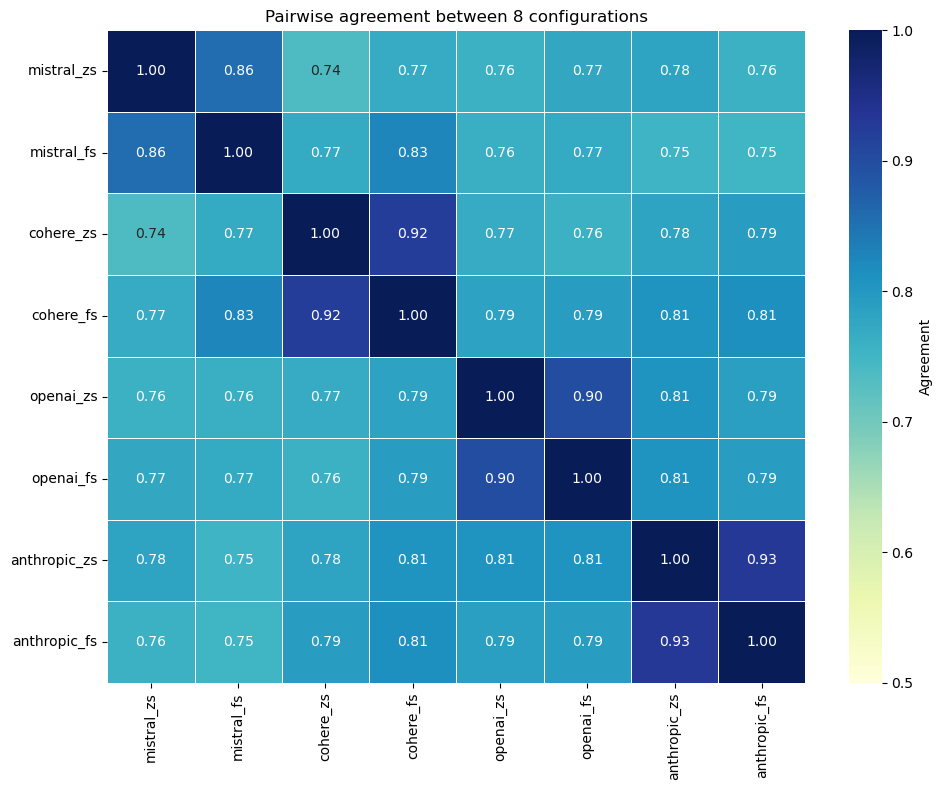

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pairwise.astype(float), annot=True, fmt=".2f", cmap="YlGnBu",
    vmin=0.5, vmax=1.0, cbar_kws={"label": "Agreement"}, ax=ax,
    linewidths=0.5, linecolor="white"
)
ax.set_title("Pairwise agreement between 8 configurations")
plt.tight_layout()
plt.savefig("agreement_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
def n_distinct(row):
    return len(set(row[c] for c in strategy_cols))

valid["n_distinct"] = valid.apply(n_distinct, axis=1)

print("Number of distinct labels across the 8 configurations:")
for k in sorted(valid["n_distinct"].unique()):
    cnt = (valid["n_distinct"] == k).sum()
    pct = cnt / n * 100
    print(f"  {k} distinct label(s): {cnt} utterances ({pct:.1f}%)")

print(f"\nFull agreement (all 8 configurations pick the same strategy): "
      f"{(valid['n_distinct']==1).sum()} / {n} = {(valid['n_distinct']==1).mean()*100:.1f}%")

Number of distinct labels across the 8 configurations:
  1 distinct label(s): 192 utterances (55.0%)
  2 distinct label(s): 126 utterances (36.1%)
  3 distinct label(s): 30 utterances (8.6%)
  4 distinct label(s): 1 utterances (0.3%)

Full agreement (all 8 configurations pick the same strategy): 192 / 349 = 55.0%


In [6]:
outlier_counts = Counter()
consensus_count = 0

for _, row in valid.iterrows():
    labels = {c: row[f"{c}_strategy1"] for c in CONFIGS}
    cnt = Counter(labels.values())
    most_common_label, most_common_n = cnt.most_common(1)[0]
    if most_common_n == 7:
        # ровно одна конфигурация отличается от остальных семи
        consensus_count += 1
        outlier = [c for c, lab in labels.items() if lab != most_common_label][0]
        outlier_counts[outlier] += 1

print(f"Cases of 7-vs-1 (seven configurations agree, one differs): {consensus_count}\n")
print("How often each configuration is the odd one out:")
for c in CONFIGS:
    cnt = outlier_counts.get(c, 0)
    pct = cnt / consensus_count * 100 if consensus_count else 0
    print(f"  {c:<14} {cnt:>3}  ({pct:.1f}% of 7-vs-1 cases)")

Cases of 7-vs-1 (seven configurations agree, one differs): 41

How often each configuration is the odd one out:
  mistral_zs       7  (17.1% of 7-vs-1 cases)
  mistral_fs       9  (22.0% of 7-vs-1 cases)
  cohere_zs       10  (24.4% of 7-vs-1 cases)
  cohere_fs        0  (0.0% of 7-vs-1 cases)
  openai_zs        4  (9.8% of 7-vs-1 cases)
  openai_fs        6  (14.6% of 7-vs-1 cases)
  anthropic_zs     2  (4.9% of 7-vs-1 cases)
  anthropic_fs     3  (7.3% of 7-vs-1 cases)


In [7]:
rows = []
for c in CONFIGS:
    others = [o for o in CONFIGS if o != c]
    avg_agreement_with_others = np.mean([pairwise.loc[c, o] for o in others])
    rows.append({
        "configuration": c,
        "avg_agreement_with_other_7": round(avg_agreement_with_others, 3),
        "odd_one_out_count": outlier_counts.get(c, 0),
    })
summary = pd.DataFrame(rows).sort_values("avg_agreement_with_other_7")
print("Most different from the others (top of the table):\n")
print(summary.to_string(index=False))

Most different from the others (top of the table):

configuration  avg_agreement_with_other_7  odd_one_out_count
   mistral_zs                       0.776                  7
   mistral_fs                       0.784                  9
    cohere_zs                       0.790                 10
    openai_zs                       0.796                  4
    openai_fs                       0.800                  6
 anthropic_fs                       0.804                  3
 anthropic_zs                       0.810                  2
    cohere_fs                       0.817                  0


In [8]:
print("Self-agreement (zero-shot vs few-shot) for each base model:\n")
for m in MODELS:
    agree = pairwise.loc[f"{m}_zs", f"{m}_fs"]
    print(f"  {m:<10} zs vs fs agreement: {agree:.3f}")

print("\nAverage agreement among configurations sharing the same prompting:\n")
for p in PROMPTING:
    configs_p = [f"{m}_{p}" for m in MODELS]
    pairs = list(combinations(configs_p, 2))
    avg = np.mean([pairwise.loc[a, b] for a, b in pairs])
    print(f"  {p}: {avg:.3f}")

Self-agreement (zero-shot vs few-shot) for each base model:

  mistral    zs vs fs agreement: 0.857
  cohere     zs vs fs agreement: 0.923
  openai     zs vs fs agreement: 0.900
  anthropic  zs vs fs agreement: 0.931

Average agreement among configurations sharing the same prompting:

  zs: 0.772
  fs: 0.791


In [9]:
rows = []
for gold_label, sub in valid.groupby("gold_strategy1"):
    full_agree = (sub["n_distinct"] == 1).sum()
    rows.append({
        "gold_strategy": gold_label,
        "n_utterances": len(sub),
        "full_agreement": full_agree,
        "full_agreement_pct": round(full_agree / len(sub) * 100, 1),
    })

strategy_agreement = pd.DataFrame(rows).sort_values("full_agreement_pct", ascending=False)
print("Per-strategy agreement (sorted easy -> hard):\n")
print(strategy_agreement.to_string(index=False))

Per-strategy agreement (sorted easy -> hard):

     gold_strategy  n_utterances  full_agreement  full_agreement_pct
       no_strategy            87              60                69.0
        accusation           123              83                67.5
      presentation            71              29                40.8
            appeal            23               9                39.1
self-justification            45              11                24.4


In [10]:
max_distinct = valid["n_distinct"].max()
hard = valid[valid["n_distinct"] == max_distinct].copy()
print(f"Maximum number of distinct labels on a single utterance: {max_distinct}")
print(f"Utterances at that maximum: {len(hard)}\n")

for i, (_, r) in enumerate(hard.head(5).iterrows()):
    print(f"--- Example {i+1} ---")
    print(f"Speaker: {r['speaker']}")
    print(f"Gold:      {r['gold_strategy1']}")
    for c in CONFIGS:
        print(f"  {c:<14} {r[f'{c}_strategy1']}")
    print(f"Text: {r['text'][:300]}{'...' if len(r['text']) > 300 else ''}")
    print()

Maximum number of distinct labels on a single utterance: 4
Utterances at that maximum: 1

--- Example 1 ---
Speaker: WALZ
Gold:      presentation
  mistral_zs     no_strategy
  mistral_fs     no_strategy
  cohere_zs      no_strategy
  cohere_fs      no_strategy
  openai_zs      presentation
  openai_fs      presentation
  anthropic_zs   accusation
  anthropic_fs   appeal
Text: What are the federal regulations? I deal with this as a Governor.



In [11]:
from sklearn.metrics import cohen_kappa_score

kappa = pd.DataFrame(index=CONFIGS, columns=CONFIGS, dtype=float)
for a in CONFIGS:
    for b in CONFIGS:
        kappa.loc[a, b] = cohen_kappa_score(valid[f"{a}_strategy1"], valid[f"{b}_strategy1"])

print("Pairwise Cohen's kappa (>0.6 substantial, >0.4 moderate, <0.4 weak):\n")
print(kappa.round(3))

print("\nAverage kappa with the other seven (lower = more different from the rest):")
for c in CONFIGS:
    others = [o for o in CONFIGS if o != c]
    avg_k = np.mean([kappa.loc[c, o] for o in others])
    print(f"  {c:<14} {avg_k:.3f}")

Pairwise Cohen's kappa (>0.6 substantial, >0.4 moderate, <0.4 weak):

              mistral_zs  mistral_fs  cohere_zs  cohere_fs  openai_zs  \
mistral_zs         1.000       0.811      0.652      0.692      0.678   
mistral_fs         0.811       1.000      0.701      0.771      0.688   
cohere_zs          0.652       0.701      1.000      0.898      0.694   
cohere_fs          0.692       0.771      0.898      1.000      0.715   
openai_zs          0.678       0.688      0.694      0.715      1.000   
openai_fs          0.700       0.701      0.685      0.728      0.866   
anthropic_zs       0.703       0.674      0.709      0.742      0.739   
anthropic_fs       0.675       0.670      0.722      0.748      0.711   

              openai_fs  anthropic_zs  anthropic_fs  
mistral_zs        0.700         0.703         0.675  
mistral_fs        0.701         0.674         0.670  
cohere_zs         0.685         0.709         0.722  
cohere_fs         0.728         0.742         0.748  
op

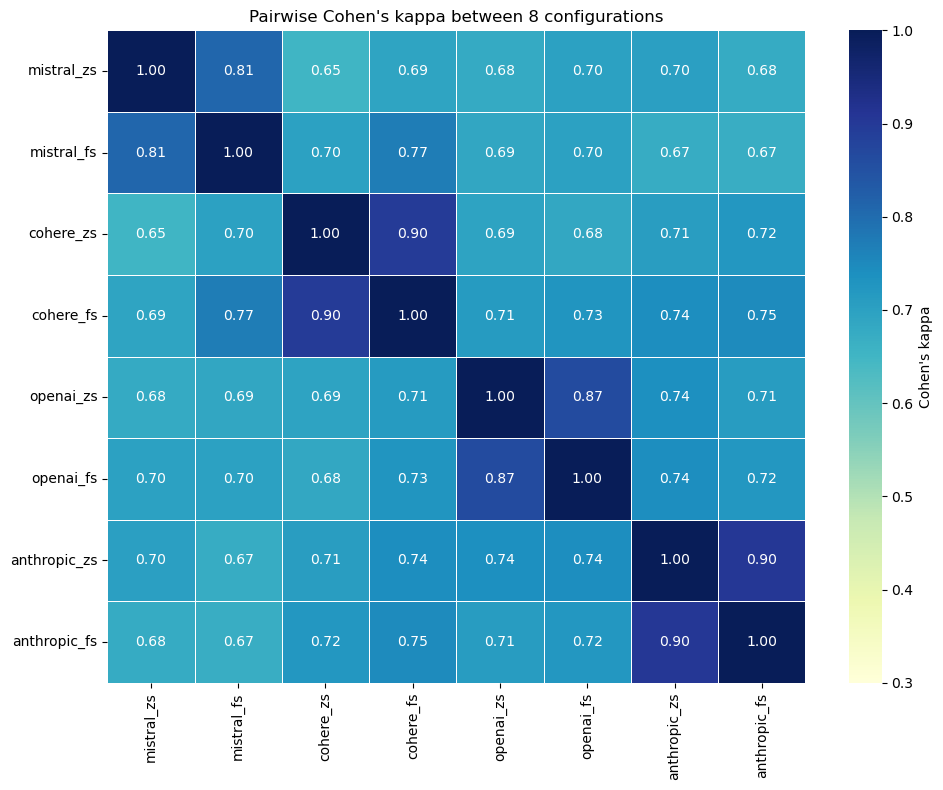

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    kappa.astype(float), annot=True, fmt=".2f", cmap="YlGnBu",
    vmin=0.3, vmax=1.0, cbar_kws={"label": "Cohen's kappa"}, ax=ax,
    linewidths=0.5, linecolor="white"
)
ax.set_title("Pairwise Cohen's kappa between 8 configurations")
plt.tight_layout()
plt.savefig("kappa_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

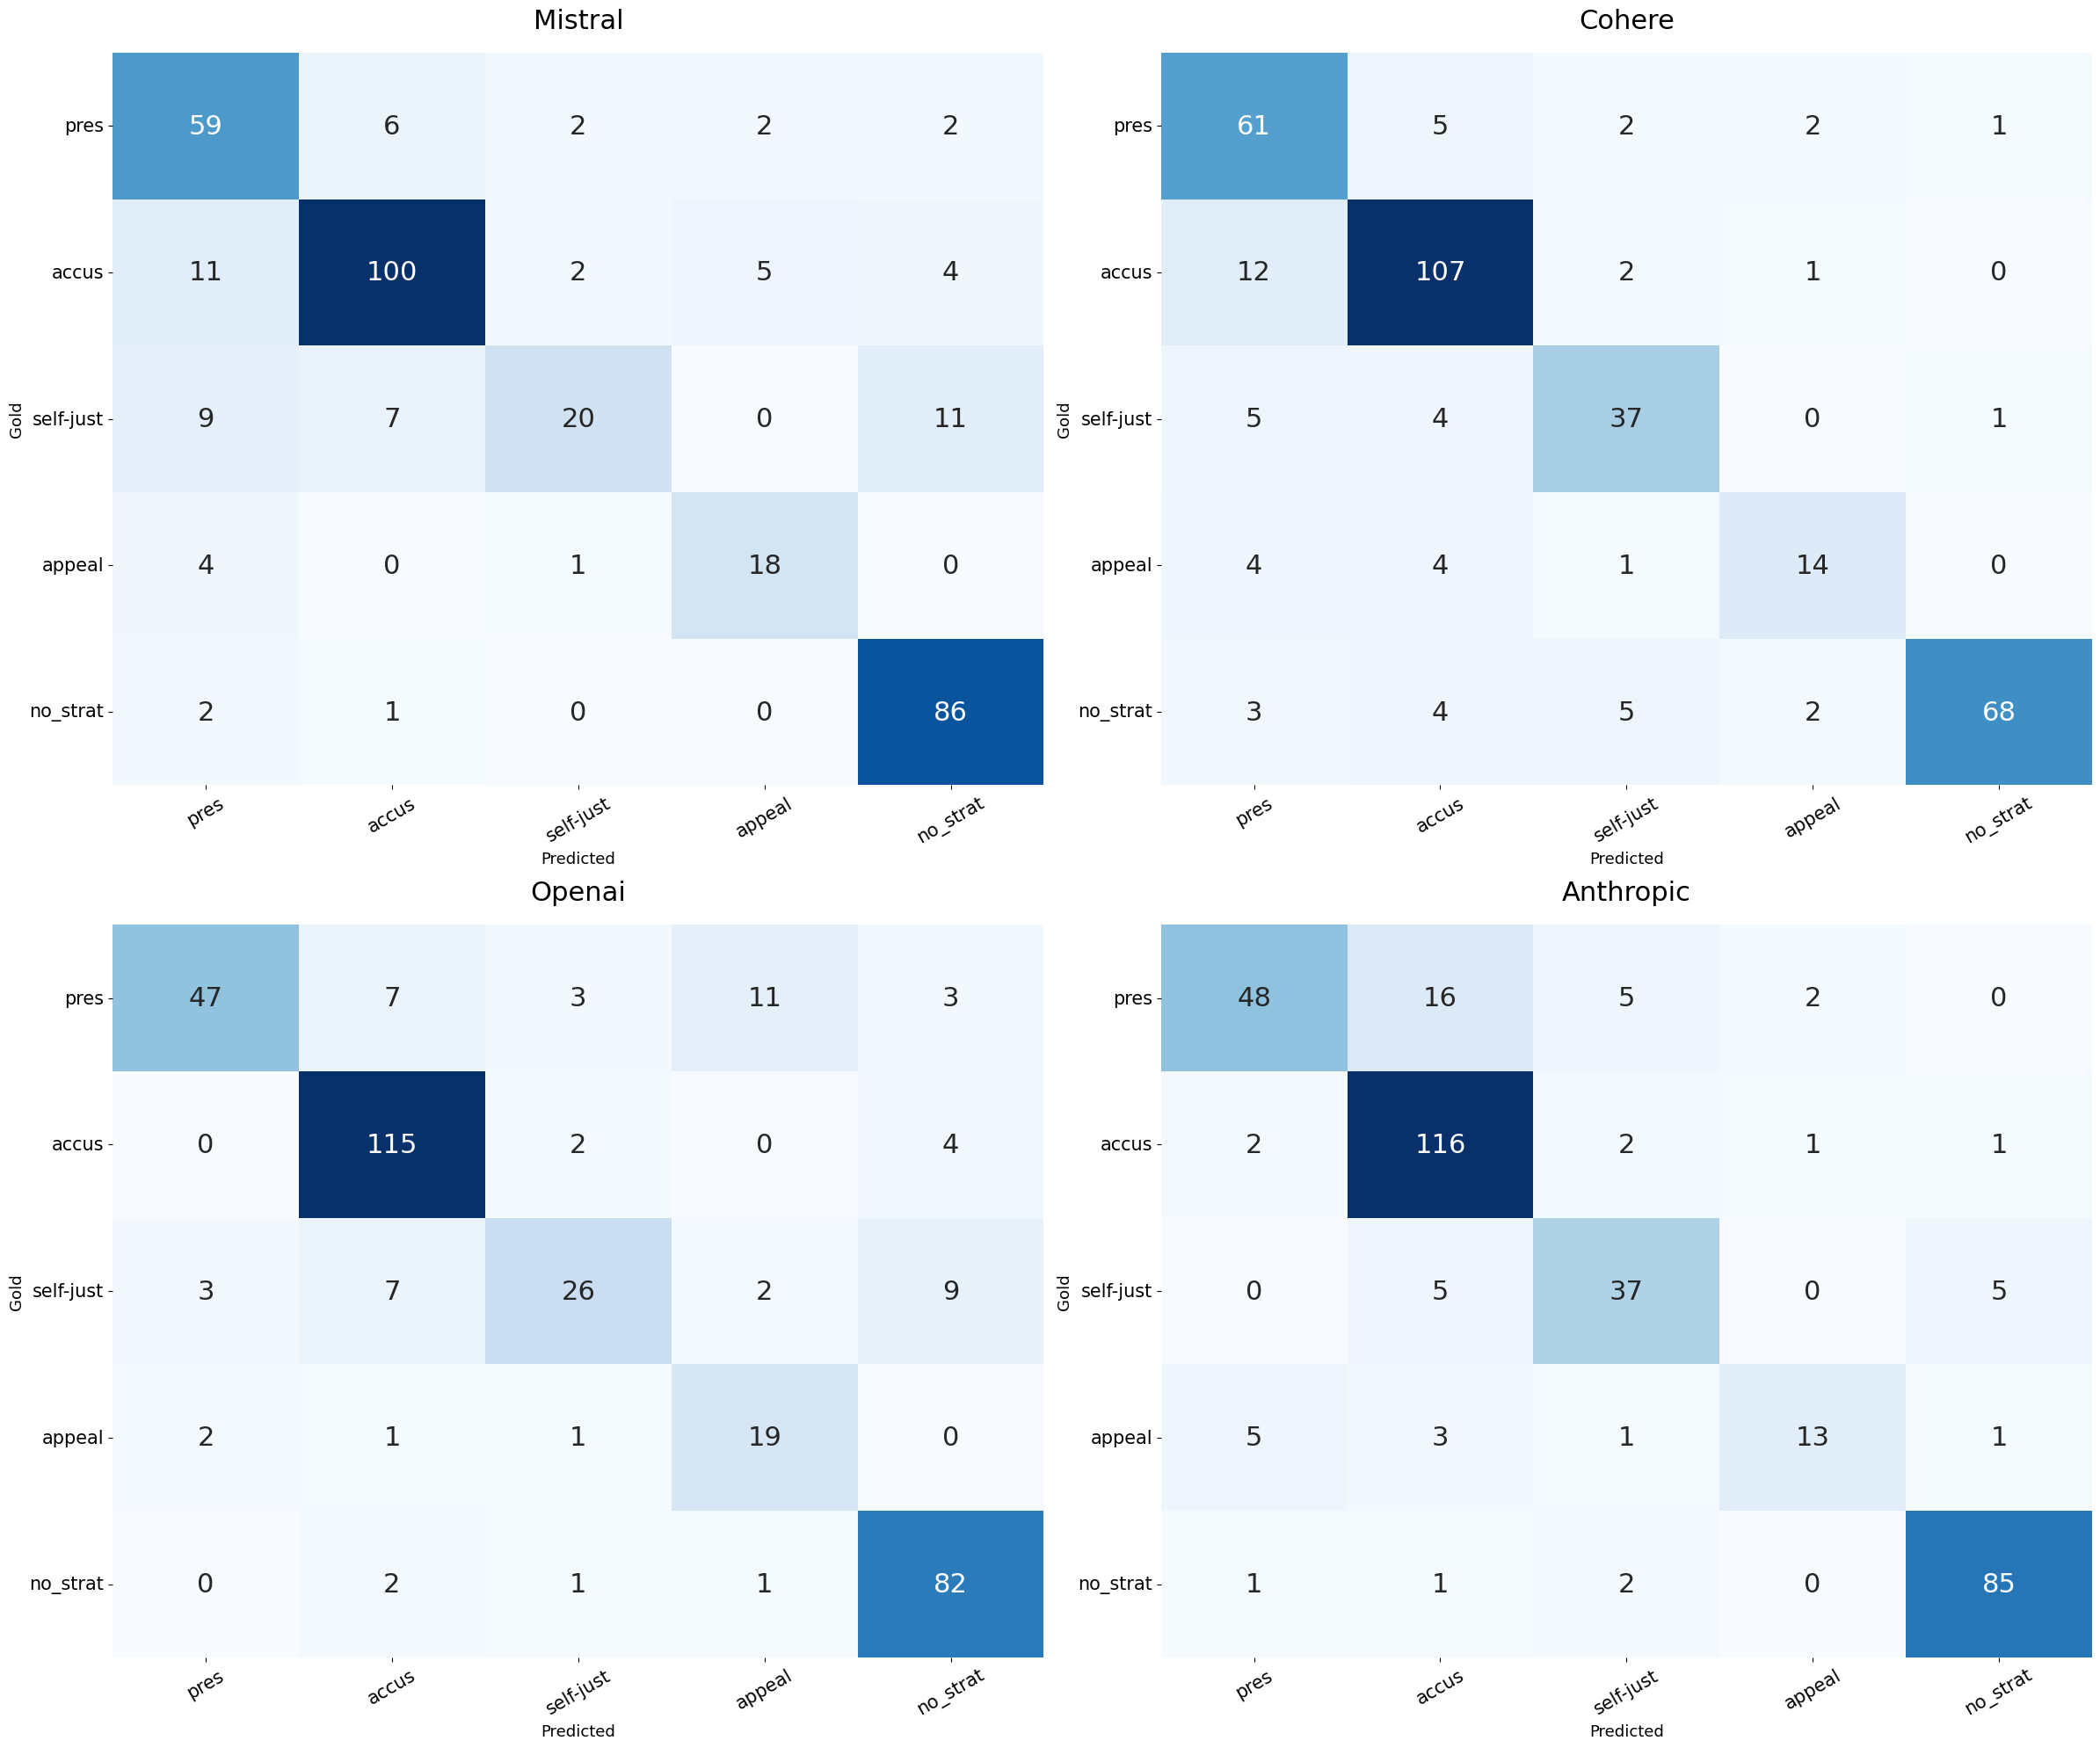

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import math

ALL_STRATEGIES = [
    'presentation',
    'accusation',
    'self-justification',
    'appeal',
    'no_strategy'
]

SHORT_LABELS = {
    'presentation': 'pres',
    'accusation': 'accus',
    'appeal': 'appeal',
    'self-justification': 'self-just',
    'no_strategy': 'no_strat'
}

SHORT_NAMES = [SHORT_LABELS[s] for s in ALL_STRATEGIES]

MODELS = ["mistral", "cohere", "openai", "anthropic"]

eval_df = zs.copy()

n_models = len(MODELS)
n_cols = 2
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(24, 10 * n_rows)
)

axes = axes.flatten()

for idx, model_name in enumerate(MODELS):

    temp_df = eval_df[
        ["gold_strategy1", f"{model_name}_strategy1"]
    ].copy()

    temp_df = temp_df.dropna()

    y_true = temp_df["gold_strategy1"].astype(str)
    y_pred = temp_df[f"{model_name}_strategy1"].astype(str)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=ALL_STRATEGIES
    )

    sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=SHORT_NAMES,
    yticklabels=SHORT_NAMES,
    ax=axes[idx],
    cbar=False,
    annot_kws={"size": 22}
    )

    axes[idx].set_title(
        f"{model_name.capitalize()}",
        fontsize=22,
        pad=20
    )

    axes[idx].set_xlabel(
        "Predicted",
        fontsize=13
    )

    axes[idx].set_ylabel(
        "Gold",
        fontsize=13
    )

    # названия стратегий
    axes[idx].tick_params(
        axis='x',
        rotation=30,
        labelsize=15
    )

    axes[idx].tick_params(
        axis='y',
        rotation=0,
        labelsize=15
    )

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    "zero_shot_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

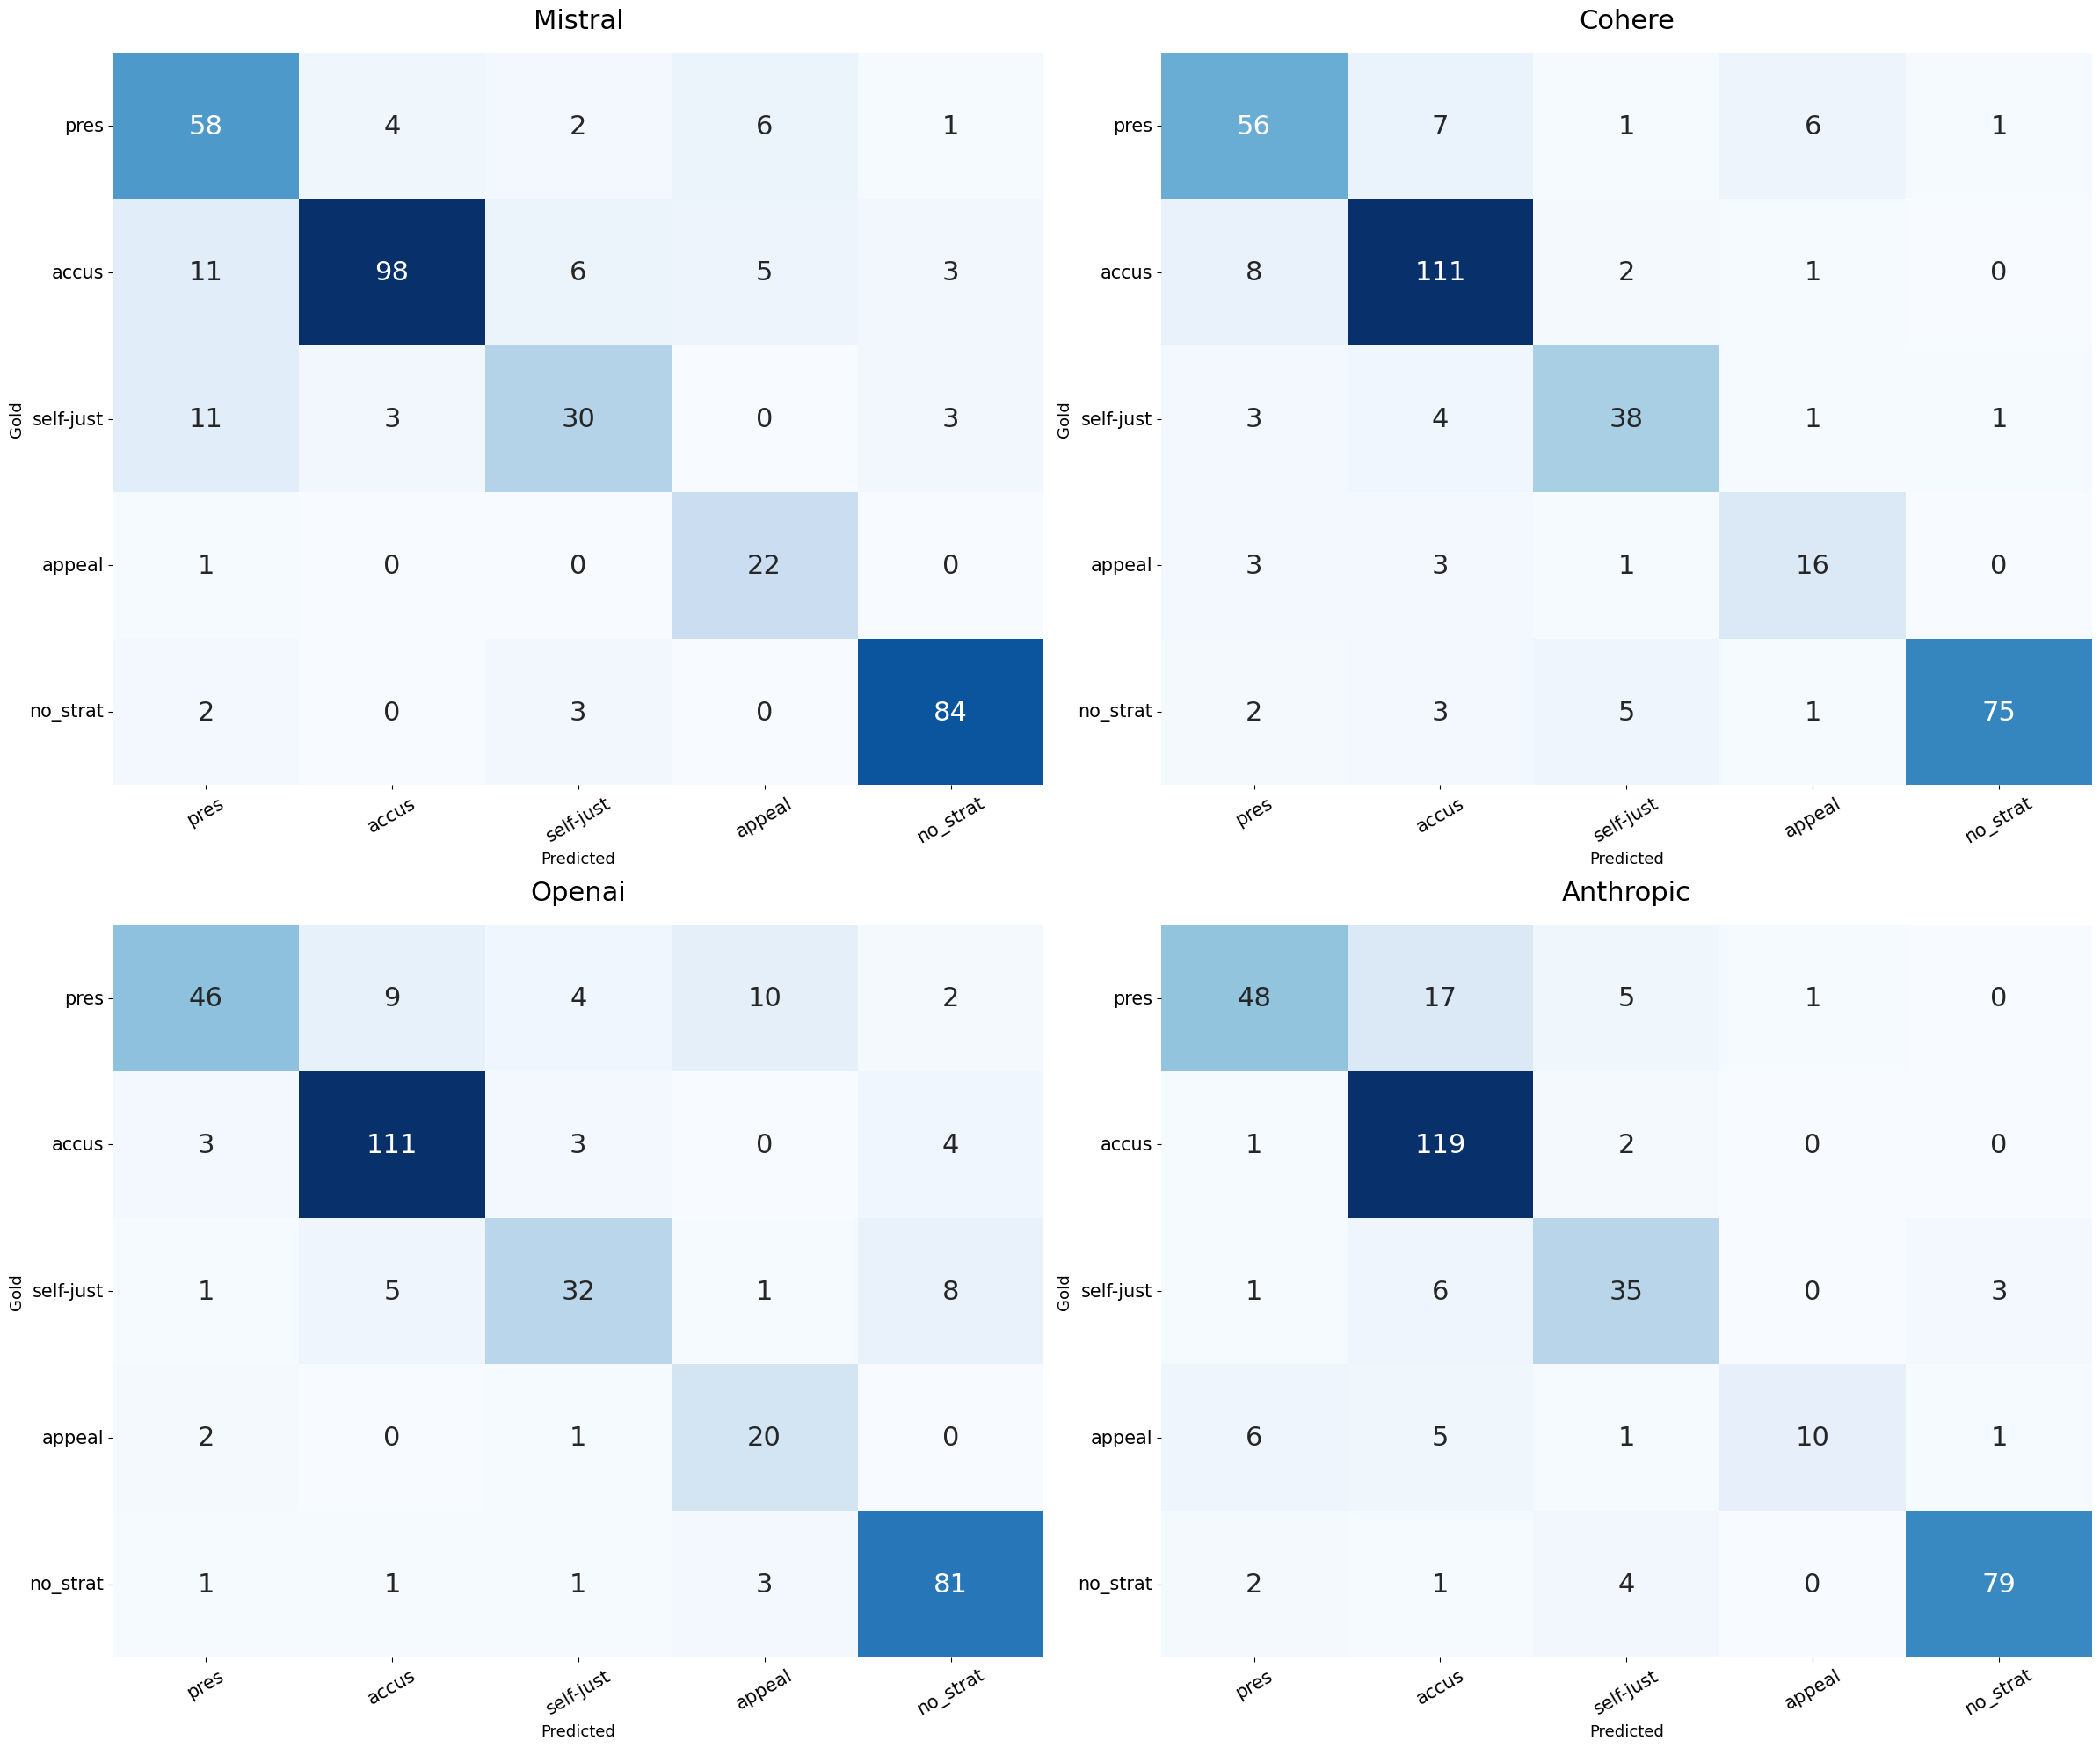

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import math
import pandas as pd

ALL_STRATEGIES = [
    'presentation',
    'accusation',
    'self-justification',
    'appeal',
    'no_strategy'
]

SHORT_LABELS = {
    'presentation': 'pres',
    'accusation': 'accus',
    'appeal': 'appeal',
    'self-justification': 'self-just',
    'no_strategy': 'no_strat'
}

SHORT_NAMES = [SHORT_LABELS[s] for s in ALL_STRATEGIES]

MODELS = ["mistral", "cohere", "openai", "anthropic"]

eval_df = fs.copy()

n_models = len(MODELS)
n_cols = 2
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(24, 10 * n_rows)
)

axes = axes.flatten()

for idx, model_name in enumerate(MODELS):

    temp_df = eval_df[
        ["gold_strategy1", f"{model_name}_strategy1"]
    ].copy()

    temp_df = temp_df.dropna()
    temp_df["gold_strategy1"] = temp_df["gold_strategy1"].astype(str)
    temp_df[f"{model_name}_strategy1"] = temp_df[f"{model_name}_strategy1"].astype(str)

    y_true = temp_df["gold_strategy1"]
    y_pred = temp_df[f"{model_name}_strategy1"]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=ALL_STRATEGIES
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=SHORT_NAMES,
        yticklabels=SHORT_NAMES,
        ax=axes[idx],
        cbar=False,
        annot_kws={"size": 22}
    )

    axes[idx].set_title(
        f"{model_name.capitalize()}",
        fontsize=22,
        pad=20
    )

    axes[idx].set_xlabel(
        "Predicted",
        fontsize=13
    )

    axes[idx].set_ylabel(
        "Gold",
        fontsize=13
    )

    axes[idx].tick_params(
        axis='x',
        rotation=30,
        labelsize=15
    )

    axes[idx].tick_params(
        axis='y',
        rotation=0,
        labelsize=15
    )

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    "few_shot_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()